# EDA & Data Cleaning

In [11]:
import os
import pandas as pd, numpy as np
import matplotlib.pyplot as plt

DATA_PATH = os.environ.get("DATA_PATH", "\Dev\sap-cxii-tech-ex-01\data\marketing_sample_for_amazon_com-amazon_fashion_products__20200201_20200430__30k_data.ldjson")
df = pd.read_json(DATA_PATH, lines=True)
print("shape:", df.shape)
df.columns.tolist()

shape: (30000, 33)


['uniq_id',
 'crawl_timestamp',
 'asin',
 'product_url',
 'product_name',
 'image_urls__small',
 'medium',
 'large',
 'browsenode',
 'brand',
 'sales_price',
 'weight',
 'rating',
 'sales_rank_in_parent_category',
 'sales_rank_in_child_category',
 'delivery_type',
 'meta_keywords',
 'amazon_prime__y_or_n',
 'parent___child_category__all',
 'best_seller_tag__y_or_n',
 'other_items_customers_buy',
 'product_details__k_v_pairs',
 'discount_percentage',
 'colour',
 'no__of_reviews',
 'seller_name',
 'seller_id',
 'left_in_stock',
 'no__of_offers',
 'no__of_sellers',
 'technical_details__k_v_pairs',
 'formats___editions',
 'name_of_author_for_books']

## 1. Missingness audit

In [12]:
df.isna().mean().sort_values()

uniq_id                          0.000000
best_seller_tag__y_or_n          0.000000
amazon_prime__y_or_n             0.000000
delivery_type                    0.000000
rating                           0.000000
weight                           0.000000
meta_keywords                    0.000000
crawl_timestamp                  0.000000
asin                             0.000000
product_name                     0.000000
product_url                      0.000000
medium                           0.000067
image_urls__small                0.000067
browsenode                       0.017333
large                            0.038633
product_details__k_v_pairs       0.039433
sales_price                      0.096333
sales_rank_in_parent_category    0.150100
parent___child_category__all     0.150100
sales_rank_in_child_category     0.171633
other_items_customers_buy        0.187900
brand                            0.271433
discount_percentage              0.512533
seller_id                        0

Most columns are mostly empty. The reliably-present fields are product_name,
meta_keywords, the image URLs, rating. The assignment's named
numeric attributes (price, weight) are either absent or sparse — there is no
price column at all; sales_price (~90%) is the only price signal.

In [13]:
df["weight"].value_counts(dropna=False).head(6)

weight
999999999    23745
200 g          736
249 g          689
299 g          398
399 g          304
349 g          259
Name: count, dtype: int64

999999999 is a placeholder for "unknown" and accounts for ~79% of rows. Real
values are clean gram strings (200 g). So weight's *true* coverage is ~20%:

In [14]:
sentinel = (df["weight"].astype(str).str.strip() == "999999999").mean()
real = df["weight"].astype(str).str.contains(r" g\b", na=False, regex=True).mean()
print(f"sentinel: {sentinel:.1%}   real (grams): {real:.1%}")

sentinel: 79.1%   real (grams): 20.4%


zero-rating share: 0.0
range of non-zero: 1.0 - 5.0


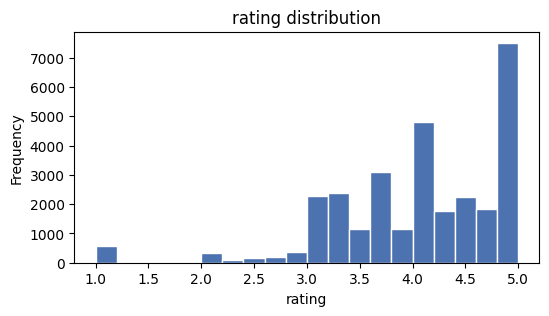

In [15]:
print("zero-rating share:", (df["rating"] == 0).mean())
print("range of non-zero:", df.loc[df.rating > 0, "rating"].min(), "-", df["rating"].max())
ax = df["rating"].plot.hist(bins=20, figsize=(6,3), color="#4C72B0", edgecolor="white")
ax.set_title("rating distribution")
ax.set_xlabel("rating")
plt.show()

Unlike weight, rating is genuinely real: a full 1–5 scale with no 0.0
placeholder, so no "unrated" trap. It's the strongest numeric feature we have.

count    27110.0
mean       862.2
std        964.2
min         39.0
25%        379.0
50%        590.0
75%        899.0
max       9988.0
Name: sales_price, dtype: float64


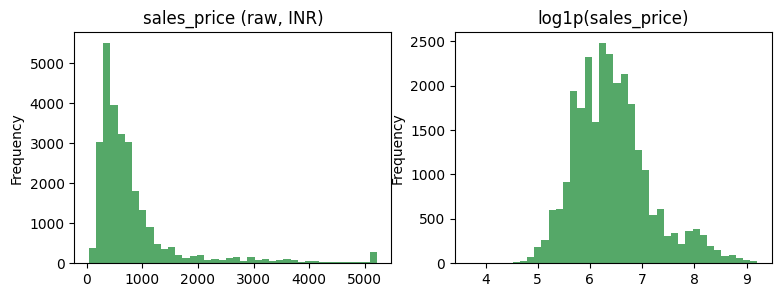

In [16]:
print(df["sales_price"].describe().round(1))
fig, ax = plt.subplots(1, 2, figsize=(9,3))
df["sales_price"].dropna().clip(upper=df["sales_price"].quantile(0.99)).plot.hist(bins=40, ax=ax[0], color="#55A868")
ax[0].set_title("sales_price (raw, INR)")
np.log1p(df["sales_price"].dropna()).plot.hist(bins=40, ax=ax[1], color="#55A868")
ax[1].set_title("log1p(sales_price)")
plt.show()

Prices are in INR (amazon.in) and heavily right-skewed, so a log transform
before standardizing keeps a few luxury items from dominating the numeric distance.

In [17]:
print("brand present:", df["brand"].notna().mean())
print("colour present:", df["colour"].notna().mean())
print("colour samples:", df["colour"].dropna().head(3).tolist())
print("category type:", type(df["parent___child_category__all"].dropna().iloc[0]).__name__)
df["parent___child_category__all"].dropna().iloc[0]

brand present: 0.7285666666666667
colour present: 0.20096666666666665
colour samples: ['Black|Blue|Grey', 'Black|Navy Blue', 'Black|Maroon']
category type: dict


{'ClothingAccessories': '#19,259', 'WomensKurtasKurtis': '#1793'}

colour is multi-value (Black|Blue|Grey) and only ~20% present a fallback feature. brand is ~73% present, healthy enough to use.

parent___child_category__all is a dict mapping category names to bestseller
ranks. The first key is the parent, the last is a leaf
(WomensKurtasKurtis) which is a signal we could use for the cross-category
guard.

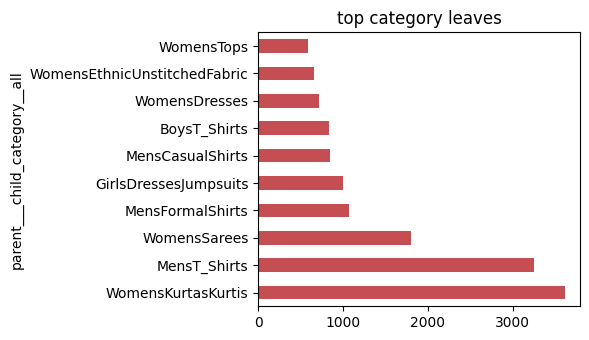

In [18]:
def leaf(d): 
    if isinstance(d, dict) and d:
        return list(d.keys())[-1]  
    else:
        None
df["parent___child_category__all"].dropna().apply(leaf).value_counts().head(10).plot.barh(
    figsize=(6,3.5), color="#C44E52")
plt.title("top category leaves")
plt.tight_layout()
plt.show()

In [20]:
import sys, os
sys.path.insert(0, os.path.abspath(".."))
from product_similarity import clean
out = clean.clean(df)
out.notna().mean().sort_values(ascending=False).round(3)

uniq_id            1.000
product_name       1.000
meta_keywords      1.000
rating             1.000
product_url        1.000
image_url          1.000
sales_price        0.904
category_parent    0.850
category_leaf      0.850
brand              0.729
weight_g           0.204
colour             0.201
dtype: float64

## 7. Findings

- No price. Use sales_price (~90%).
- weight ~20% real and colour ~20%.
- rating clean 1–5 and sales_price the two reliable numeric features.
- Text (product_name + meta_keywords) is the backbone. always present and
  material/style/gender live in the name.
- Category leaf (from the dict) is the cross-category guard.
- Everything seller/offer/stock/review-count related is too sparse to use.